### Abdulla Abudahab ____________________________________________________ID:2401245052

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


---
## Task 1 — Exploratory Data Analysis (EDA)

### 1.1 Load Dataset & Shape

In [4]:
df = pd.read_csv('car_price.csv')
df.columns = [c.strip().lower() for c in df.columns]

print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows   : 72435
Columns: 10


,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize,make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


### 1.2 Feature Types

In [5]:
numerical   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical features  :', numerical)
print('Categorical features:', categorical)
print()
print(df.dtypes)

Numerical features  : ['year', 'price', 'mileage', 'tax', 'mpg', 'enginesize']
Categorical features: ['model', 'transmission', 'fueltype', 'make']

model            object
year            float64
price           float64
transmission     object
mileage         float64
fueltype         object
tax             float64
mpg             float64
enginesize      float64
make             object
dtype: object


### 1.3 Missing Values

In [6]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df  = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)
missing_df

,Count,Percentage (%)
transmission,3623,5.0
year,3622,5.0
fueltype,3622,5.0
mileage,3622,5.0
enginesize,3622,5.0
model,3621,5.0
price,3621,5.0
tax,3621,5.0
mpg,3621,5.0
make,3621,5.0


### 1.4 Price Distribution

count     68814.000000
mean      16583.919261
std        9304.412707
min         495.000000
25%       10167.250000
50%       14495.000000
75%       20359.750000
max      145000.000000
Name: price, dtype: float64


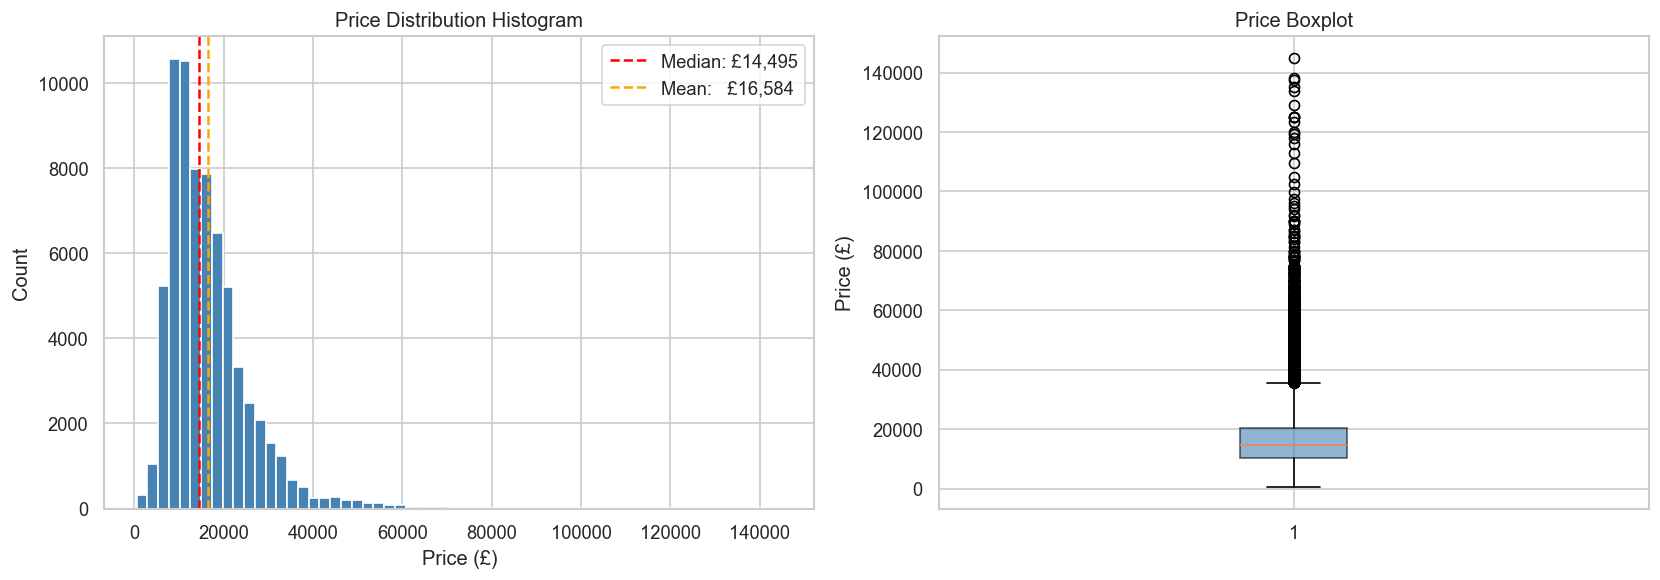

In [7]:
print(df['price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(df['price'].median(), color='red',    linestyle='--',
                label=f'Median: \u00a3{df["price"].median():,.0f}')
axes[0].axvline(df['price'].mean(),   color='orange', linestyle='--',
                label=f'Mean:   \u00a3{df["price"].mean():,.0f}')
axes[0].set_title('Price Distribution Histogram')
axes[0].set_xlabel('Price (\u00a3)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(df['price'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Price Boxplot')
axes[1].set_ylabel('Price (\u00a3)')

plt.tight_layout()
plt.show()

### 1.5 Correlation Heatmap

Correlation with price:
price         1.000000
enginesize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


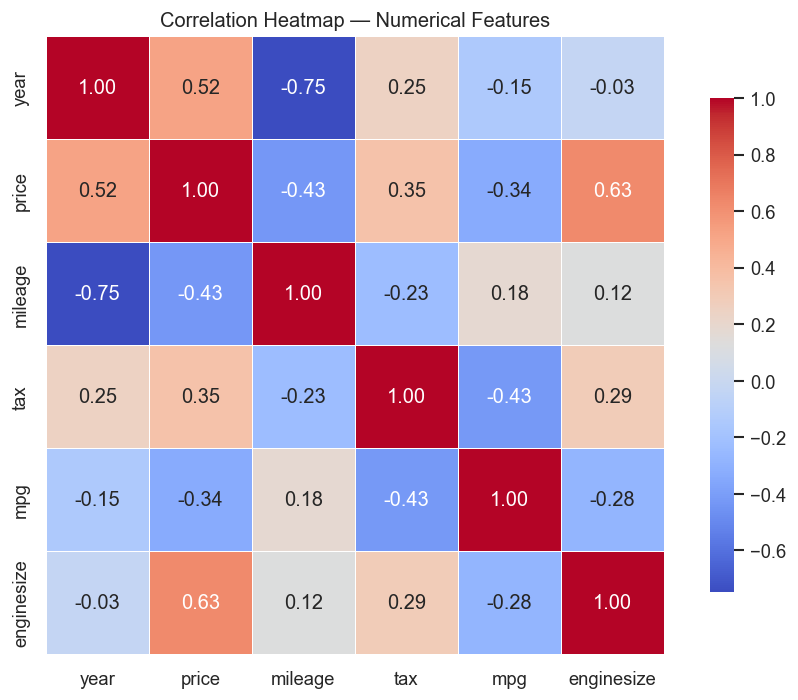

In [8]:
num_cols = ['year', 'price', 'mileage', 'tax', 'mpg', 'enginesize']
corr = df[num_cols].corr()

print('Correlation with price:')
print(corr['price'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

### 1.6 Price by Make & Fuel Type

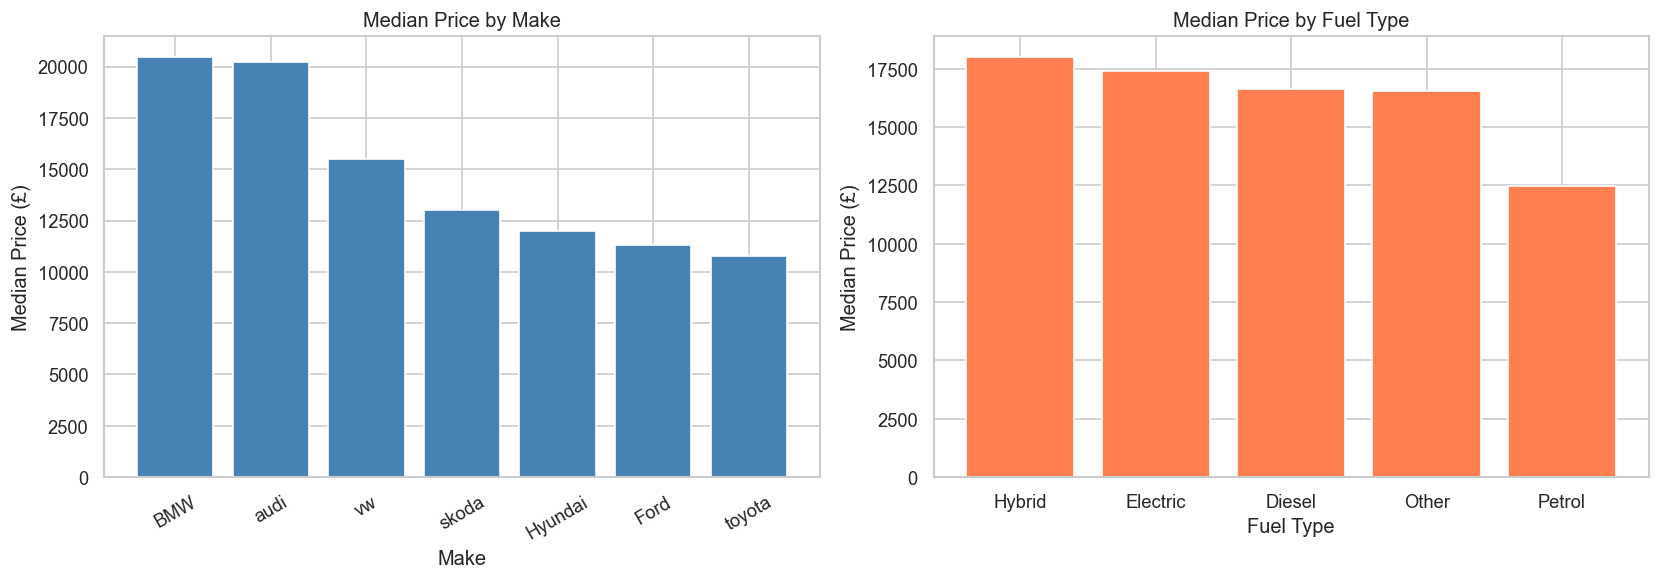

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

make_price = df.groupby('make')['price'].median().sort_values(ascending=False)
axes[0].bar(make_price.index, make_price.values, color='steelblue', edgecolor='white')
axes[0].set_title('Median Price by Make')
axes[0].set_xlabel('Make')
axes[0].set_ylabel('Median Price (\u00a3)')
axes[0].tick_params(axis='x', rotation=30)

fuel_price = df.groupby('fueltype')['price'].median().sort_values(ascending=False)
axes[1].bar(fuel_price.index, fuel_price.values, color='coral', edgecolor='white')
axes[1].set_title('Median Price by Fuel Type')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Median Price (\u00a3)')

plt.tight_layout()
plt.show()

---
## Task 2 — Data Preprocessing

### Step 1 — Drop rows with missing price (target column)

In [10]:
data = df.copy()

print(f'Rows before: {len(data)}')
data.dropna(subset=['price'], inplace=True)
print(f'Rows after : {len(data)}')

Rows before: 72435
Rows after : 68814


### Step 2 — Encode Categorical Features
Done **before** splitting to guarantee the same dummy columns appear in both train and test.

- `transmission`, `fueltype`, `make`, `model` → **One-Hot Encoding** (no natural order)
- `drop_first=True` removes one dummy per group to avoid multicollinearity.

In [11]:
data = pd.get_dummies(data, columns=['transmission', 'fueltype', 'make', 'model'], drop_first=True)

print(f'Shape after encoding: {data.shape}')
print(f'Columns sample: {list(data.columns[:10])}')

Shape after encoding: (68814, 163)
Columns sample: ['year', 'price', 'mileage', 'tax', 'mpg', 'enginesize', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'fueltype_Electric']


### Step 3 — Train / Test Split (**once** for both models)
> Split happens **once** here — before imputation, outlier removal, and scaling.
> `y_cls` is derived from `y_test_r` / `y_train_r` after the split so both models share **exactly the same rows**.

In [12]:
X     = data.drop(columns=['price'])
y_reg = data['price']

# Define price category thresholds from full y before split
q1 = y_reg.quantile(0.33)
q2 = y_reg.quantile(0.66)

def price_category(p):
    if p < q1:    return 'Cheap'
    elif p <= q2: return 'Moderate'
    else:         return 'Expensive'

le    = LabelEncoder()
y_cls = y_reg.apply(price_category)
le.fit(y_cls)   # fit on full set so all classes are known


X_train, X_test, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Derive classification targets from the SAME indices
y_train_c = le.transform(y_train_r.apply(price_category))
y_test_c  = le.transform(y_test_r.apply(price_category))

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test  size : {X_test.shape[0]}  rows')
print(f'Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Train size : 55051 rows
Test  size : 13763  rows
Class mapping: {'Cheap': np.int64(0), 'Expensive': np.int64(1), 'Moderate': np.int64(2)}


### Step 4 — Handle Missing Values (on train only, then apply to test)
Median and mode are computed **only from the training set** to avoid leakage.

In [13]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'enginesize']

X_train = X_train.copy()
X_test  = X_test.copy()

for col in num_cols:
    train_median = X_train[col].median()          # computed from train only
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col]  = X_test[col].fillna(train_median)  # same value applied to test
    print(f"'{col}' — train median = {train_median:.2f}")

print(f'\nMissing in X_train: {X_train.isnull().sum().sum()}')
print(f'Missing in X_test : {X_test.isnull().sum().sum()}')

'year' — train median = 2017.00
'mileage' — train median = 17516.00
'tax' — train median = 145.00
'mpg' — train median = 55.40
'enginesize' — train median = 1.60

Missing in X_train: 0
Missing in X_test : 0


### Step 5 — Remove Outliers (from train only)
IQR bounds computed from **training set only**. We only drop outliers from train — test stays untouched (it represents real unseen data).

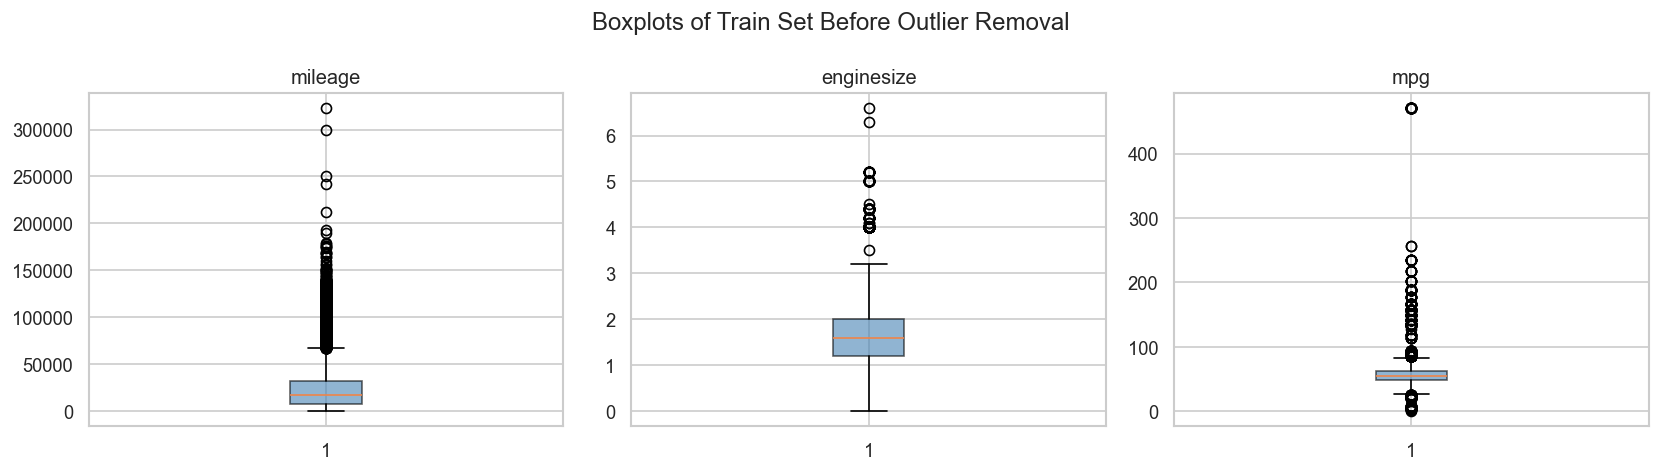

'mileage': removed 2413 outliers | bounds [-28139.0, 67369.0]
'enginesize': removed 246 outliers | bounds [-0.0, 3.2]
'mpg': removed 799 outliers | bounds [25.6, 85.1]

Train rows after outlier removal: 51727
Test  rows unchanged            : 13763


In [14]:
outlier_cols = ['mileage', 'enginesize', 'mpg']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(14, 4))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(X_train[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
plt.suptitle('Boxplots of Train Set Before Outlier Removal')
plt.tight_layout()
plt.show()

train_mask = pd.Series([True] * len(X_train), index=X_train.index)

for col in outlier_cols:
    Q1  = X_train[col].quantile(0.25)
    Q3  = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    col_mask = (X_train[col] >= lower) & (X_train[col] <= upper)
    removed  = (~col_mask).sum()
    train_mask &= col_mask
    print(f"'{col}': removed {removed} outliers | bounds [{lower:.1f}, {upper:.1f}]")

X_train   = X_train[train_mask]
y_train_r = y_train_r[train_mask]
y_train_c = y_train_c[train_mask]

print(f'\nTrain rows after outlier removal: {len(X_train)}')
print(f'Test  rows unchanged            : {len(X_test)}')

### Step 6 — Scale Features (fit on train, transform both)
`StandardScaler` fitted **only on training data**, then used to transform both sets.
Since both models share the same split, **one scaler** is enough for both.

In [15]:
# Both models use the same scaled X_train / X_test
scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')

X_train shape: (51727, 162)
X_test  shape: (13763, 162)


---
## Task 3 — Create Two Target Variables

### 3A — Regression Target

In [14]:
print('Regression target (price):')
print(y_reg.describe())

Regression target (price):
count     68814.000000
mean      16583.919261
std        9304.412707
min         495.000000
25%       10167.250000
50%       14495.000000
75%       20359.750000
max      145000.000000
Name: price, dtype: float64


### 3B — Classification Target

Cheap    : price < £11,450
Moderate : £11,450 – £17,995
Expensive: price > £17,995

 Class distribution:
price
Expensive    23172
Moderate     22968
Cheap        22674
Name: count, dtype: int64

price
Expensive    33.7%
Moderate     33.4%
Cheap        32.9%
Name: proportion, dtype: object


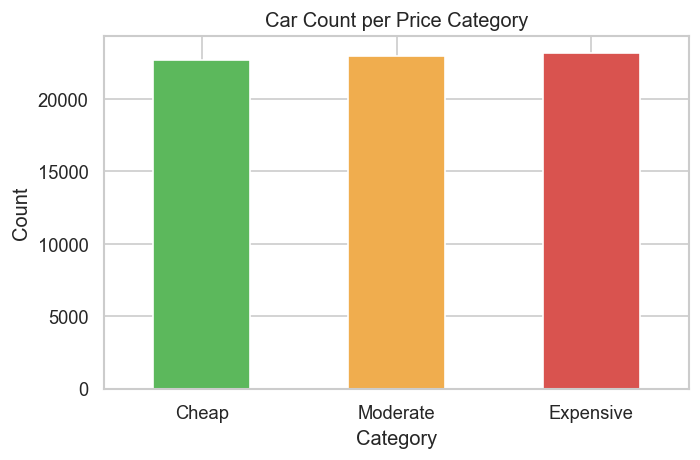

In [16]:
print(f'Cheap    : price < £{q1:,.0f}')
print(f'Moderate : £{q1:,.0f} – £{q2:,.0f}')
print(f'Expensive: price > £{q2:,.0f}')
print('\n Class distribution:')
print(y_cls.value_counts())
print()
print((y_cls.value_counts(normalize=True)*100).round(1).astype(str).add('%'))

plt.figure(figsize=(6, 4))
y_cls.value_counts()[['Cheap','Moderate','Expensive']].plot(
    kind='bar', color=['#5cb85c','#f0ad4e','#d9534f'], edgecolor='white')
plt.title('Car Count per Price Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Task 4 — Model 1: Linear Regression

### 4.1 Train the Model

In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_r)
print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')

Train: 51727 rows  |  Test: 13763 rows


### 4.2 Evaluate on Test Set

In [18]:
y_pred_r = lr_model.predict(X_test)

mae      = mean_absolute_error(y_test_r, y_pred_r)
mse      = mean_squared_error(y_test_r, y_pred_r)
rmse     = np.sqrt(mse)
r2       = r2_score(y_test_r, y_pred_r)
r2_train = r2_score(y_train_r, lr_model.predict(X_train))


print('  Linear Regression — Evaluation Metrics :')

print(f'  MAE      : £{mae:>10,.2f}')
print(f'  MSE      : £{mse:>10,.2f}')
print(f'  RMSE     : £{rmse:>10,.2f}')
print(f'  R² Train :  {r2_train:>10.4f}')
print(f'  R² Test  :  {r2:>10.4f}')

  Linear Regression — Evaluation Metrics :
  MAE      : £  2,391.40
  MSE      : £16,282,001.27
  RMSE     : £  4,035.10
  R² Train :      0.8757
  R² Test  :      0.8087


### 4.3 Predicted vs Actual + Residual Plot

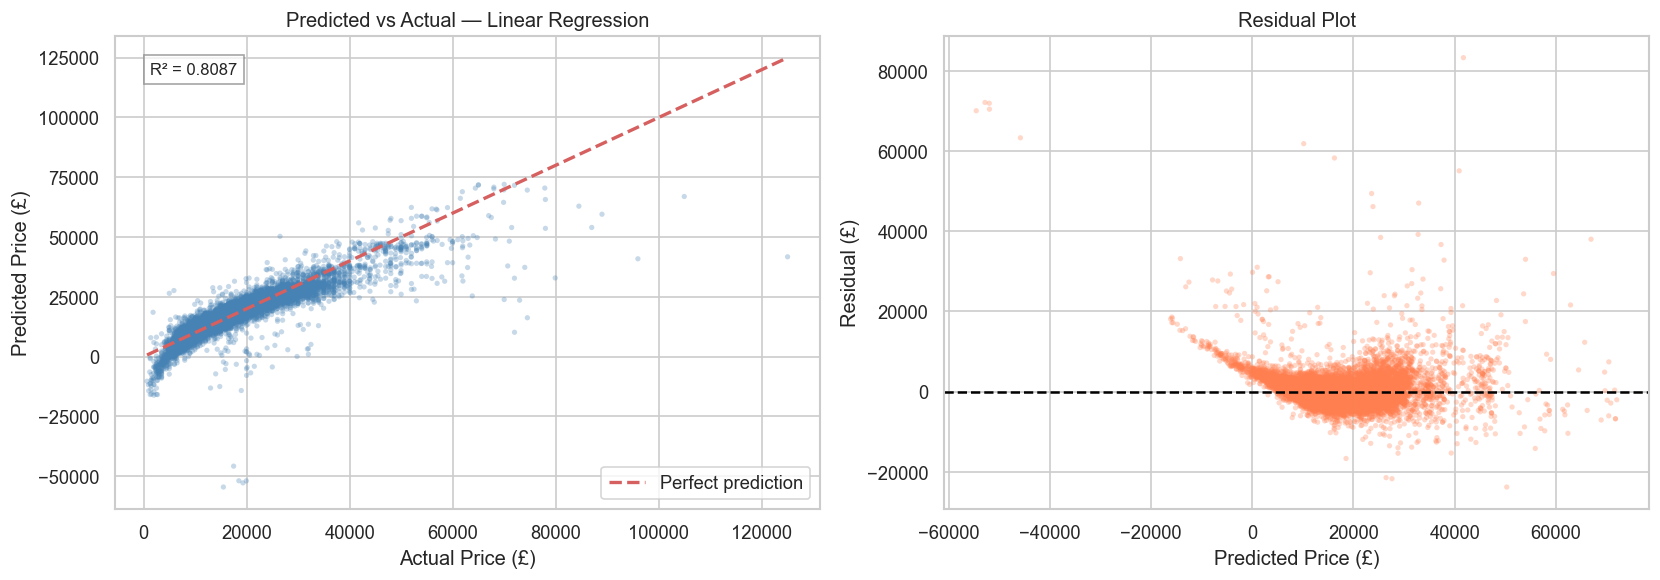

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_r, y_pred_r, alpha=0.3, color='steelblue', s=10, edgecolors='none')
mn, mx = y_test_r.min(), y_test_r.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (£)')
axes[0].set_ylabel('Predicted Price (£)')
axes[0].set_title('Predicted vs Actual — Linear Regression')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2:.4f}', transform=axes[0].transAxes,
             fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))

residuals = y_test_r.values - y_pred_r
axes[1].scatter(y_pred_r, residuals, alpha=0.3, color='coral', s=10, edgecolors='none')
axes[1].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Price (£)')
axes[1].set_ylabel('Residual (£)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

### 4.4 Top Feature Coefficients

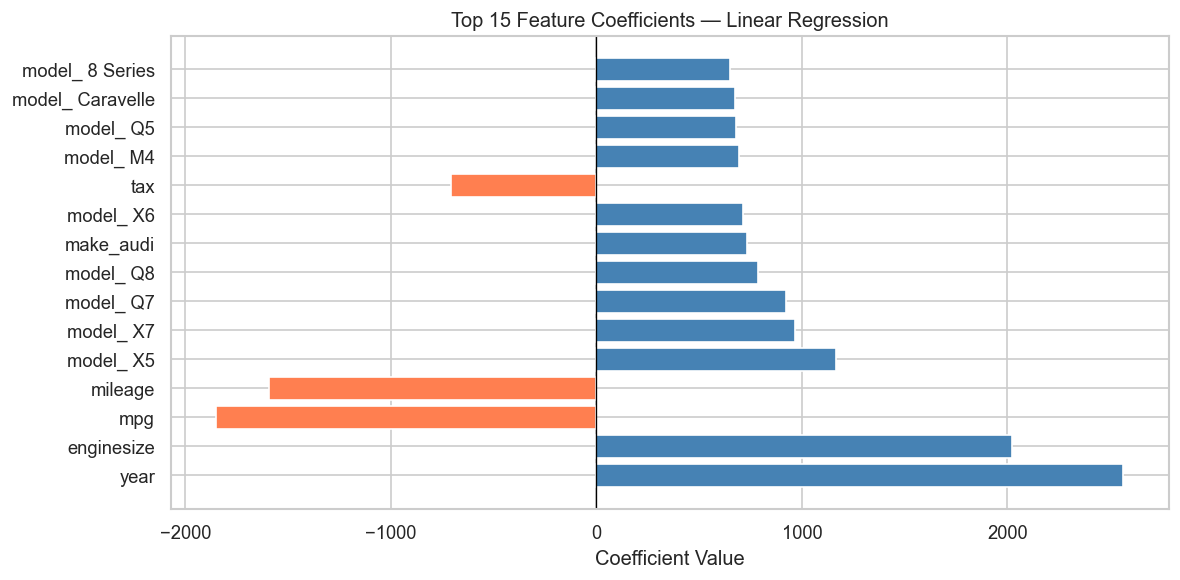

In [20]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
top15   = coef_df.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top15['Feature'],
         top15['Coefficient'],
         color=['steelblue' if c > 0 else 'coral' for c in top15['Coefficient']],
         edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients — Linear Regression')
plt.tight_layout()
plt.show()

---
## Task 5 — Model 2: KNN Classification

### 5.1 Data (same split as regression)
> No new split here — both models share the **same** `X_train` / `X_test` from Step 3.
> `y_train_c` and `y_test_c` were already derived from the same indices.

In [21]:
# No new split needed — using same X_train / X_test from Step 3
print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Train: 51727 rows  |  Test: 13763 rows
Class mapping: {'Cheap': np.int64(0), 'Expensive': np.int64(1), 'Moderate': np.int64(2)}


In [22]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric'     : ['euclidean', 'manhattan']
}

kf          = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    KNeighborsClassifier(), param_grid,
    cv=kf, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train_c)

print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best Parameters : {'metric': 'manhattan', 'n_neighbors': 7}
Best CV Accuracy: 0.8778


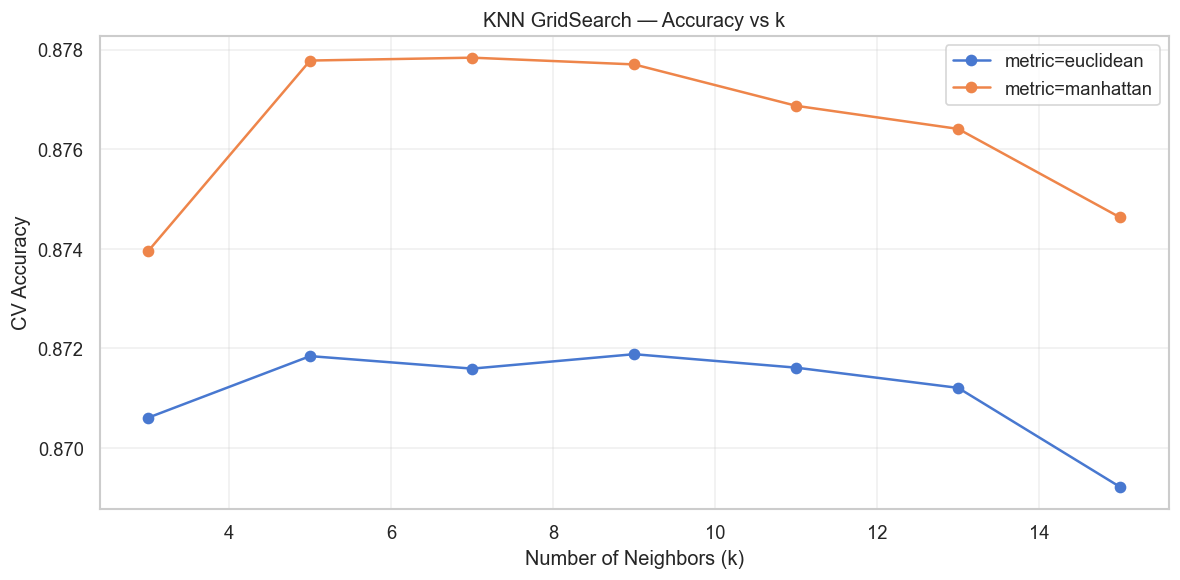

In [23]:
results_df = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10, 5))
for metric in ['euclidean', 'manhattan']:
    mask     = results_df['param_metric'] == metric
    k_vals   = results_df[mask]['param_n_neighbors'].astype(int)
    mean_acc = results_df[mask]['mean_test_score']
    plt.plot(k_vals, mean_acc, marker='o', label=f'metric={metric}')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('CV Accuracy')
plt.title('KNN GridSearch — Accuracy vs k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Evaluate Best Model

In [25]:
best_knn = grid_search.best_estimator_
y_pred_c = best_knn.predict(X_test)

acc  = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c, average='weighted')
rec  = recall_score(y_test_c, y_pred_c, average='weighted')
f1   = f1_score(y_test_c, y_pred_c, average='weighted')

print('=' * 45)
print('  KNN Classification — Evaluation Metrics')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}  (weighted)')
print(f'  Recall    : {rec:.4f}  (weighted)')
print(f'  F1-Score  : {f1:.4f}  (weighted)')
print('=' * 45)
print()
print(classification_report(y_test_c, y_pred_c, target_names=le.classes_))

  KNN Classification — Evaluation Metrics
  Accuracy  : 0.8741
  Precision : 0.8748  (weighted)
  Recall    : 0.8741  (weighted)
  F1-Score  : 0.8743  (weighted)

              precision    recall  f1-score   support

       Cheap       0.91      0.87      0.89      4482
   Expensive       0.91      0.92      0.91      4629
    Moderate       0.81      0.83      0.82      4652

    accuracy                           0.87     13763
   macro avg       0.88      0.87      0.87     13763
weighted avg       0.87      0.87      0.87     13763



### 5.4 Confusion Matrix

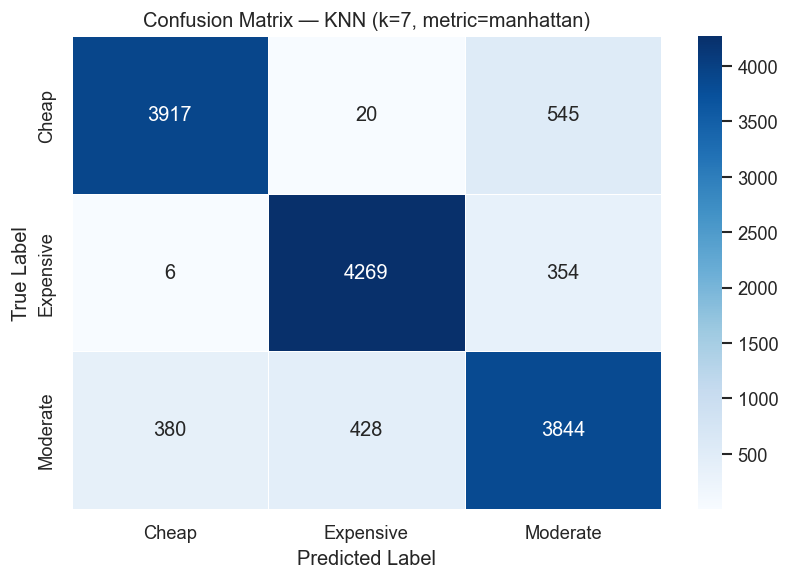

In [26]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='white')
plt.title(f'Confusion Matrix — KNN (k={grid_search.best_params_["n_neighbors"]}, metric={grid_search.best_params_["metric"]})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

---
## Task 6 — Analysis and Discussion

### 6.1 Model Comparison

In [27]:
print('  Model Comparison \n')
print(f'  Linear Regression : R²={r2:.4f} | RMSE=£{rmse:,.0f} | MAE=£{mae:,.0f}')
print(f'  KNN Classification: Accuracy={acc:.4f} | F1={f1:.4f}')
print("""
  - 'Better' depends on context:
      Regression    -> lower RMSE/MAE and higher R² is better.
      Classification -> higher Accuracy/F1 is better.

  - Classification is easier: predicting a bucket vs an exact price.
    A prediction off by £500 may still land in the right category.

  - Converting price to categories loses information.
    Cars worth £9,999 and £5,000 both become 'Cheap'.
""")

  Model Comparison 

  Linear Regression : R²=0.8087 | RMSE=£4,035 | MAE=£2,391
  KNN Classification: Accuracy=0.8741 | F1=0.8743

  - 'Better' depends on context:
      Regression    -> lower RMSE/MAE and higher R² is better.
      Classification -> higher Accuracy/F1 is better.

  - Classification is easier: predicting a bucket vs an exact price.
    A prediction off by £500 may still land in the right category.

  - Converting price to categories loses information.
    Cars worth £9,999 and £5,000 both become 'Cheap'.



### 6.2A — Remove Most Correlated Feature

In [28]:
num_feats       = ['year', 'mileage', 'tax', 'mpg', 'enginesize']
corr_with_price = X_train[num_feats].corrwith(y_train_r.reset_index(drop=True)).abs()
top_feat        = corr_with_price.idxmax()

print(f'Most correlated feature: "{top_feat}" (r={corr_with_price[top_feat]:.4f})')

X_train_no = X_train.drop(columns=[top_feat])
X_test_no  = X_test.drop(columns=[top_feat])
r2_no_top  = r2_score(y_test_r,
               LinearRegression().fit(X_train_no, y_train_r).predict(X_test_no))

print(f'R² WITH    "{top_feat}": {r2:.4f}')
print(f'R² WITHOUT "{top_feat}": {r2_no_top:.4f}')
print(f'Change: {r2_no_top - r2:+.4f}')

Most correlated feature: "enginesize" (r=0.6353)
R² WITH    "enginesize": 0.8087
R² WITHOUT "enginesize": 0.7593
Change: -0.0494


### 6.2B — KNN Without Scaling

In [29]:
best_k      = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']

# Use the same train/test rows but WITHOUT scaling
X_train_raw = X.loc[X_train.index]
X_test_raw  = X.loc[X_test.index]

knn_unscaled = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_unscaled.fit(X_train_raw, y_train_c)
acc_unscaled = accuracy_score(y_test_c, knn_unscaled.predict(X_test_raw))

print(f'Accuracy WITH    scaling: {acc:.4f}')
print(f'Accuracy WITHOUT scaling: {acc_unscaled:.4f}')
print(f'Performance drop        : {acc - acc_unscaled:+.4f}')
print('Without scaling, mileage dominates distances -> worse accuracy.')

KeyError: '[58, 183, 208, 221, 238, 304, 460, 472, 482, 483, 494, 511, 579, 597, 610, 660, 668, 681, 691, 749, 784, 788, 809, 819, 844, 897, 903, 907, 909, 930, 944, 947, 964, 1007, 1012, 1014, 1082, 1086, 1090, 1110, 1116, 1177, 1197, 1249, 1253, 1268, 1277, 1350, 1361, 1393, 1398, 1399, 1407, 1411, 1434, 1442, 1495, 1560, 1564, 1617, 1648, 1659, 1669, 1695, 1708, 1711, 1729, 1737, 1753, 1757, 1764, 1772, 1788, 1820, 1859, 1890, 1901, 1923, 1994, 1999, 2003, 2017, 2022, 2036, 2148, 2172, 2188, 2232, 2257, 2259, 2264, 2302, 2367, 2381, 2382, 2393, 2411, 2475, 2476, 2494, 2497, 2538, 2571, 2635, 2639, 2642, 2649, 2695, 2708, 2733, 2738, 2780, 2815, 2841, 2845, 2892, 2894, 2914, 2916, 2940, 2951, 2956, 2958, 3010, 3015, 3063, 3065, 3091, 3099, 3128, 3181, 3187, 3221, 3291, 3294, 3296, 3305, 3321, 3327, 3349, 3365, 3382, 3442, 3446, 3447, 3451, 3474, 3490, 3494, 3561, 3563, 3616, 3694, 3749, 3786, 3789, 3849, 3852, 3885, 3899, 3904, 3914, 3923, 3924, 3952, 3963, 3969, 3982, 3994, 4014, 40

### 6.2C — Different Price Thresholds

In [30]:
threshold_tests = [
    (y_reg.quantile(0.25), y_reg.quantile(0.75), 'Q1/Q3 split'),
    (q1,                   q2,                   'Tertile split (original)'),
    (10_000,               20_000,               'Fixed: 10k / 20k'),
]

print(f'{"Threshold":<30} {"Accuracy":>10}')
print('-' * 42)
for low, high, label in threshold_tests:
    # Derive new y from the same train/test split
    y_tr_tmp = y_train_r.apply(lambda p: 0 if p < low else (1 if p <= high else 2))
    y_te_tmp = y_test_r.apply(lambda p: 0 if p < low else (1 if p <= high else 2))
    knn_tmp  = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
    knn_tmp.fit(X_train, y_tr_tmp)
    print(f'{label:<30} {accuracy_score(y_te_tmp, knn_tmp.predict(X_test)):>10.4f}')

print('\nBalanced thresholds (tertile) give the most honest evaluation.')

Threshold                        Accuracy
------------------------------------------
Q1/Q3 split                        0.8779
Tertile split (original)           0.8748
Fixed: 10k / 20k                   0.8777

Balanced thresholds (tertile) give the most honest evaluation.


---
## Task 7 — Additional Visualizations

### Extra Plot 1 — Price vs Mileage
Shows the negative relationship between mileage and price — confirms mileage as a strong predictor.

LinAlgError: SVD did not converge in Linear Least Squares

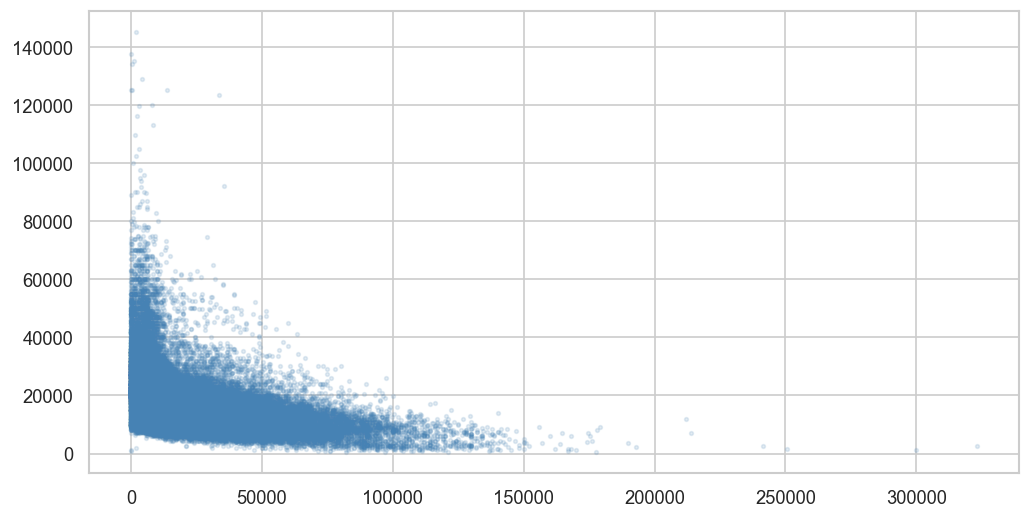

In [31]:
plt.figure(figsize=(10, 5))
plt.scatter(data['mileage'], y_reg, alpha=0.15, s=5, color='steelblue')
z      = np.polyfit(data['mileage'], y_reg, 1)
p_line = np.poly1d(z)
x_line = np.linspace(data['mileage'].min(), data['mileage'].max(), 200)
plt.plot(x_line, p_line(x_line), 'r--', lw=2, label='Trend line')
plt.xlabel('Mileage')
plt.ylabel('Price (£)')
plt.title('Price vs Mileage — Negative Trend')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Extra Plot 2 — Median Price by Year
Newer cars are consistently priced higher — confirms year as a key predictor.

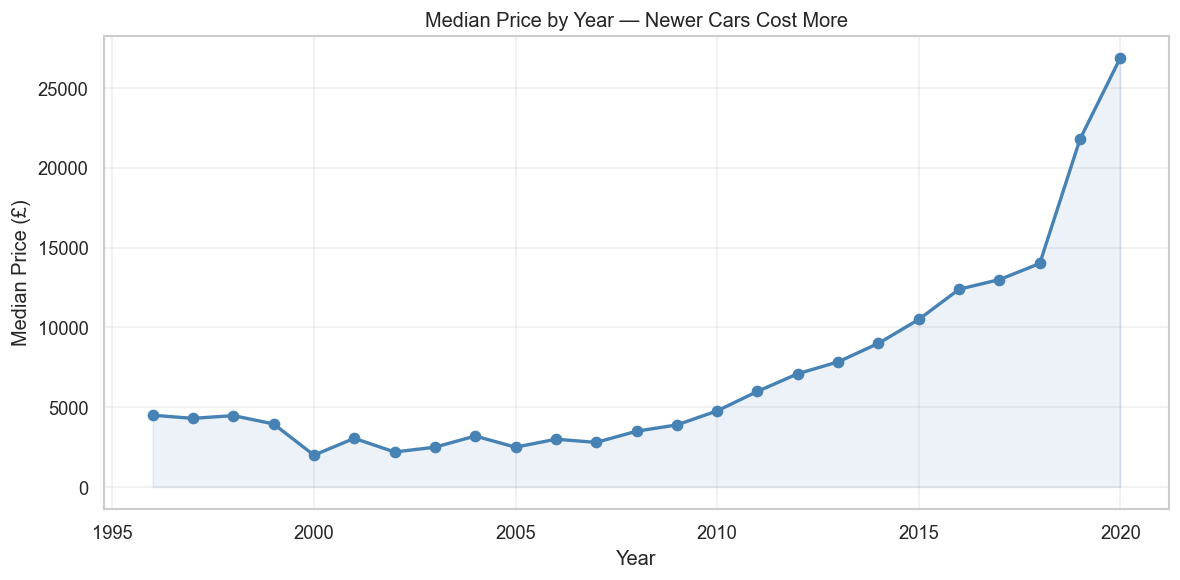

In [32]:
year_price = data.groupby('year')['price'].median().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(year_price['year'], year_price['price'],
         marker='o', color='steelblue', linewidth=2, markersize=6)
plt.fill_between(year_price['year'], year_price['price'], alpha=0.1, color='steelblue')
plt.xlabel('Year')
plt.ylabel('Median Price (£)')
plt.title('Median Price by Year — Newer Cars Cost More')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Final Summary

In [34]:
print('=' * 55)
print('  FINAL SUMMARY')
print('=' * 55)
# print(f'  Dataset rows (after cleaning) : {len(X_train_r) + len(X_test_r)}')
print(f'  Features                      : {X.shape[1]}')
print()
print('  Linear Regression')
print(f'    MAE    : £{mae:>10,.2f}')
print(f'    RMSE   : £{rmse:>10,.2f}')
print(f'    R² Test:  {r2:>10.4f}')
print()
print('  KNN Classification')
print(f'    Best k      : {grid_search.best_params_["n_neighbors"]}')
print(f'    Best metric : {grid_search.best_params_["metric"]}')
print(f'    Accuracy    : {acc:.4f}')
print(f'    F1-Score    : {f1:.4f}  (weighted)')
print('=' * 55)

  FINAL SUMMARY
  Features                      : 162

  Linear Regression
    MAE    : £  2,391.40
    RMSE   : £  4,035.10
    R² Test:      0.8087

  KNN Classification
    Best k      : 7
    Best metric : manhattan
    Accuracy    : 0.8741
    F1-Score    : 0.8743  (weighted)


## Thank YOU______________________________________________________________________________________